# **Fluorescence Reconstruction of Synthetic Fluorophores**

This notebook demonstrates **3D tomographic reconstruction** in a **fluorescence microscopy regime** using a set of **synthetic fluorophores** embedded in a 3D volume.
The fluorophores represent localized emitters — binary regions that either **emit light** or remain **dark** — providing a controlled test object for evaluating emission-based tomography.

In contrast to Brightfield imaging, the **fluorescence forward model** is purely *emissive*:
the detected signal corresponds to light emitted from within the sample, integrated along the optical axis.
There are no interference or phase contributions, making this a clean test of intensity-based reconstruction.

We reuse the same **tomographic reconstruction pipeline** as in previous examples — including **rotation initialization** and **gradient-based volume refinement** — but adapt the **imaging model** to fluorescence emission.

---

### **Notebook Outline**

1. **Generate the Synthetic Fluorophore Volume**
   Create a 3D binary volume containing several point-like fluorophores, normalized for stable simulation.

2. **Define the Fluorescence Imaging Model**
   Implement an emission-based imaging model where the measured intensity corresponds to the summed fluorescence signal along the chosen projection axis.

3. **Simulate Fluorescence Projections**
   Generate 2D projections under an oscillatory rotational motion to emulate experimental acquisition.

4. **Reconstruct the 3D Volume**
   Use the tomographic reconstruction framework to jointly optimize the volume and rotation parameters.

5. **Visualize and Evaluate**
   Compare the reconstructed fluorophore distribution to the ground truth volume, and assess the recovered rotation trajectory.

6. **Save Outputs**
   Export reconstructed volumes, quaternions, and projections for further quantitative or visual analysis.

---

> **Note:**
> The fluorescence regime models **emission-only intensity**, unlike Brightfield or holographic imaging, which rely on **scattering and phase contrast**.
> This notebook thus serves as a clean baseline for testing emission-based tomography with well-defined synthetic data.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [4]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


## 1. Load 3D Volume

In this example, we load a **3D volume containing ten synthetic fluorophores**, each represented as a small **2×2×2 voxel cube** within the volume.
These fluorophores act as localized light-emitting regions embedded in an otherwise dark medium, providing a clean test object for fluorescence tomography.

The volume is precomputed and stored in the `test_data/` folder, allowing for direct use without additional generation or preprocessing steps.

In [5]:
volume = np.load('../test_data/vol_fluo.npy')

In [6]:
print(f"Shape of the volume: {volume.shape}")

Shape of the volume: (64, 64, 64)


The 3D volume is stored in a `numpy` array and can be interactively visualized using the `ipyvolume` library together with `plotly`. Having it interactive and saving the `.ipynb` however make the file extremely large. Uncomment the code below for interactive plot.

In [7]:
#tomodpdt.plotting.visualize_3d_volume(volume, smooth=False)

Using sum projections along the x, y, and z axes, we can visualize the structure of the volume.

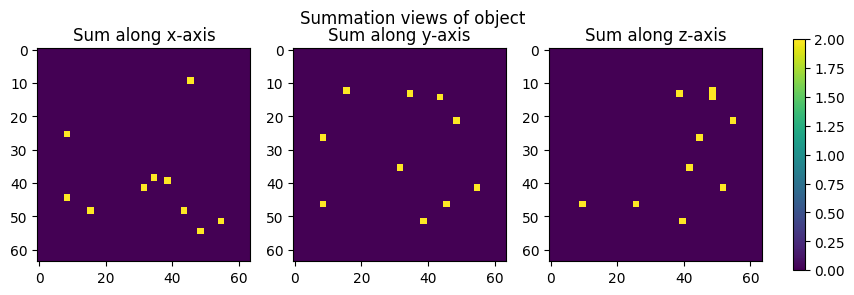

In [8]:
tomodpdt.plotting.plot_sum_object(volume)

## 2. Set Up Fluorescence Imaging Model

Fluorescence imaging relies on light emitted by **fluorophores** after excitation by an external light source.
Since the emitted light is **incoherent**, the resulting measurements contain only **intensity information**, making fluorescence tomography a **phase-free** reconstruction problem.
To simulate this modality, simply set `microscopy_regime='Fluorescence'` when defining the imaging model.

In [9]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume.shape,       # Shape of the 3D volume
    padding_xy=0,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Fluorescence', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.1,                      # Numerical Aperture of the objective
    wavelength=520e-9,           # Illumination wavelength in meters
    resolution=100e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
fluorescence_model = imaging_model(optics_setup=optics_settings)


## 3. Generate Projections

In [ ]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume, # The volume we want to reconstruct
    image_modality=fluorescence_model, # We use our fluorescence imaging model
    rotation_case='random_sinusoidal', # We rotate the object around 1 main axis, but the other 2 axes are also non-zero an
    samples=220, # Number of projections
    duration=2 # Duration is the number of full revolutions
    )

### 3.2 Visualizing the Training Data

In this section, we explore the generated training data through the forward images and the corresponding rotation parameters.

#### Vizualising the forward projections

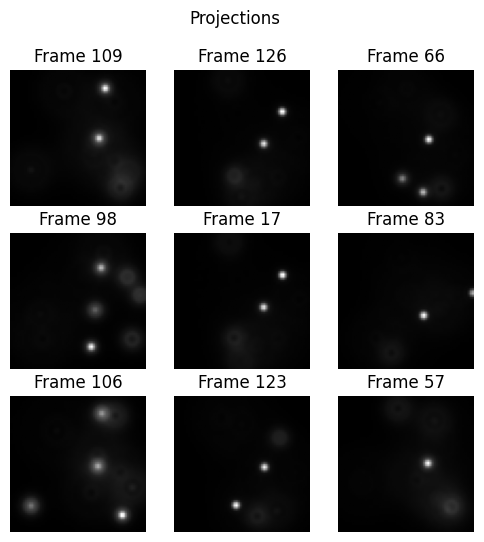

In [ ]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

#### Visualizing the Quaternion Trajectory

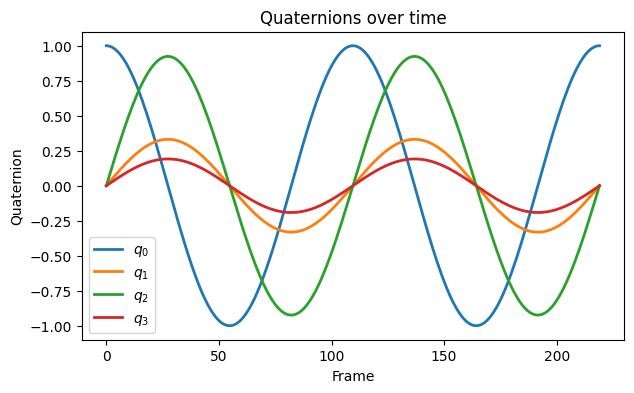

In [ ]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 4. Reconstruct the 3D Volume

In this section, we perform **tomographic reconstruction** — recovering the 3D volume from a set of 2D fluorescence projections acquired under different viewing angles.
For the fluorescence regime, the framework automatically adjusts the **loss configuration** to match the physical model.
In particular, a **binarization loss** is included to encourage the reconstructed volume to converge toward a **binary structure**, reflecting the presence or absence of fluorescent emitters.


#### Create the tomographic model

In [ ]:
#vol = np.load('reconstructed_volume_fluorescence.npy')

# Upsample the volume to 64x64x64
#vol = torch.tensor(vol, device=DEV, dtype=torch.float32)
#vol = torch.nn.functional.interpolate(vol.unsqueeze(0).unsqueeze(0), size=(64,64,64), mode='trilinear', align_corners=False).squeeze()


In [ ]:
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='basis', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=fluorescence_model, # The imaging model
    )

#### Initialize the parameters

In [ ]:
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=250, vae_beta=5e-8)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 79.2 K | train
1 | fc_mu               | MultiLayerPerceptron | 8.2 K 

Epoch 249: 100%|██████████| 7/7 [00:00<00:00, 69.69it/s, v_num=9, train_rec_loss_step=0.000738, train_KL_step=225.0, train_total_loss_step=0.000749, train_rec_loss_epoch=0.000708, train_KL_epoch=238.0, train_total_loss_epoch=0.00072]  
✅ Rotation initialization from latent space successful.


For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [ ]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

#### Visualizing the Latent Space Trajectory, Peaks and the Initial Guess


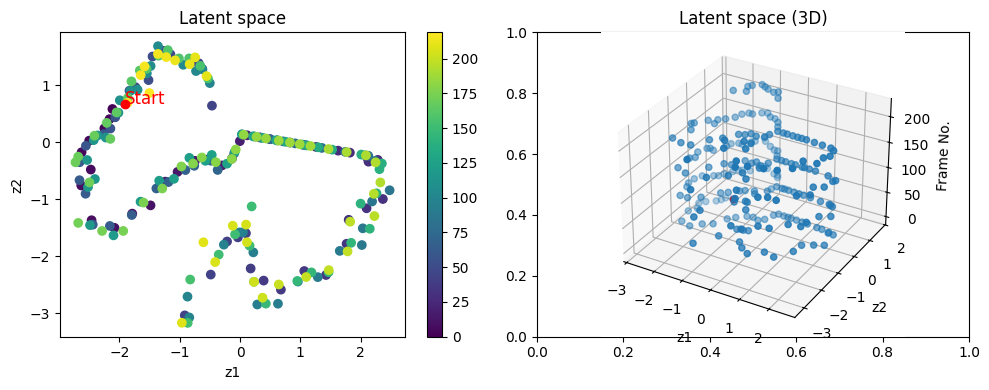

In [ ]:
plotter.plot_latent_space()

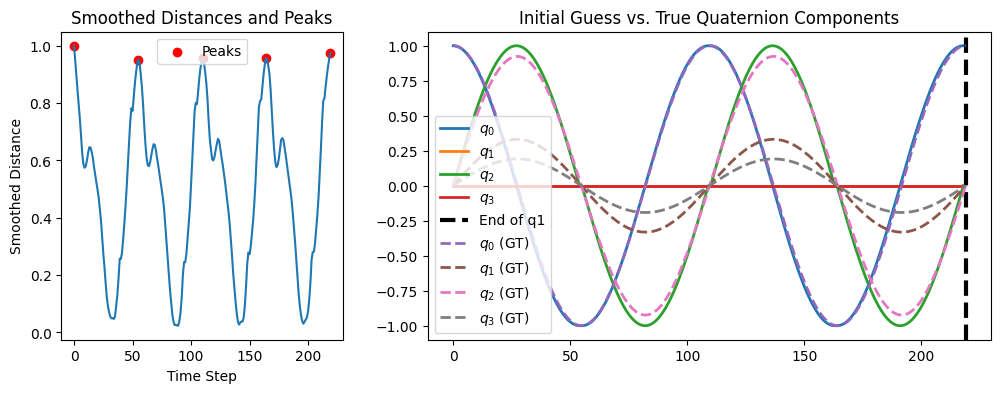

In [ ]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

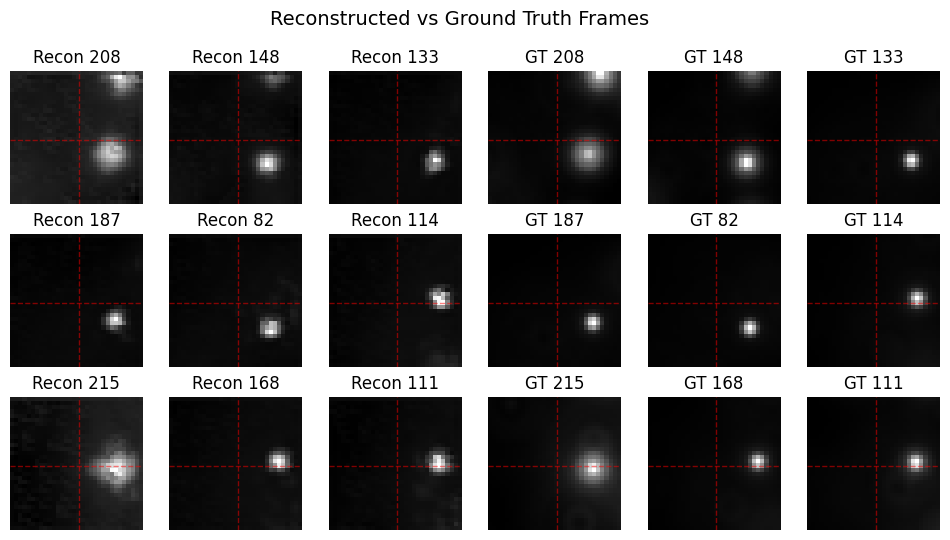

In [ ]:
plotter.plot_reconstructed_vs_gt()


### 4.1 Start the 3D Reconstruction Optimization


In [ ]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 250 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [ ]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)


  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 169 K  | train
1 | encoder       | Sequential             | 79.2 K | train
2 | fc_mu         | MultiLayerPerceptron   | 8.2 K  | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
-----------------------------------------------------------------
0         Trainable params
169 K     Non-trainable params
169 K     Total params
0.680     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches 

Epoch 249: 100%|██████████| 7/7 [00:17<00:00,  0.40it/s, v_num=10, train_latent_loss_step=1.340, train_proj_loss_step=389.0, train_binarization_loss_step=3.8e-7, train_rtv_loss_fluorescence_step=9.95e-5, train_total_loss_step=391.0, train_latent_loss_epoch=1.030, train_proj_loss_epoch=352.0, train_binarization_loss_epoch=3.8e-7, train_rtv_loss_fluorescence_epoch=9.95e-5, train_total_loss_epoch=353.0]  
Training time:  73.68678984244664  minutes


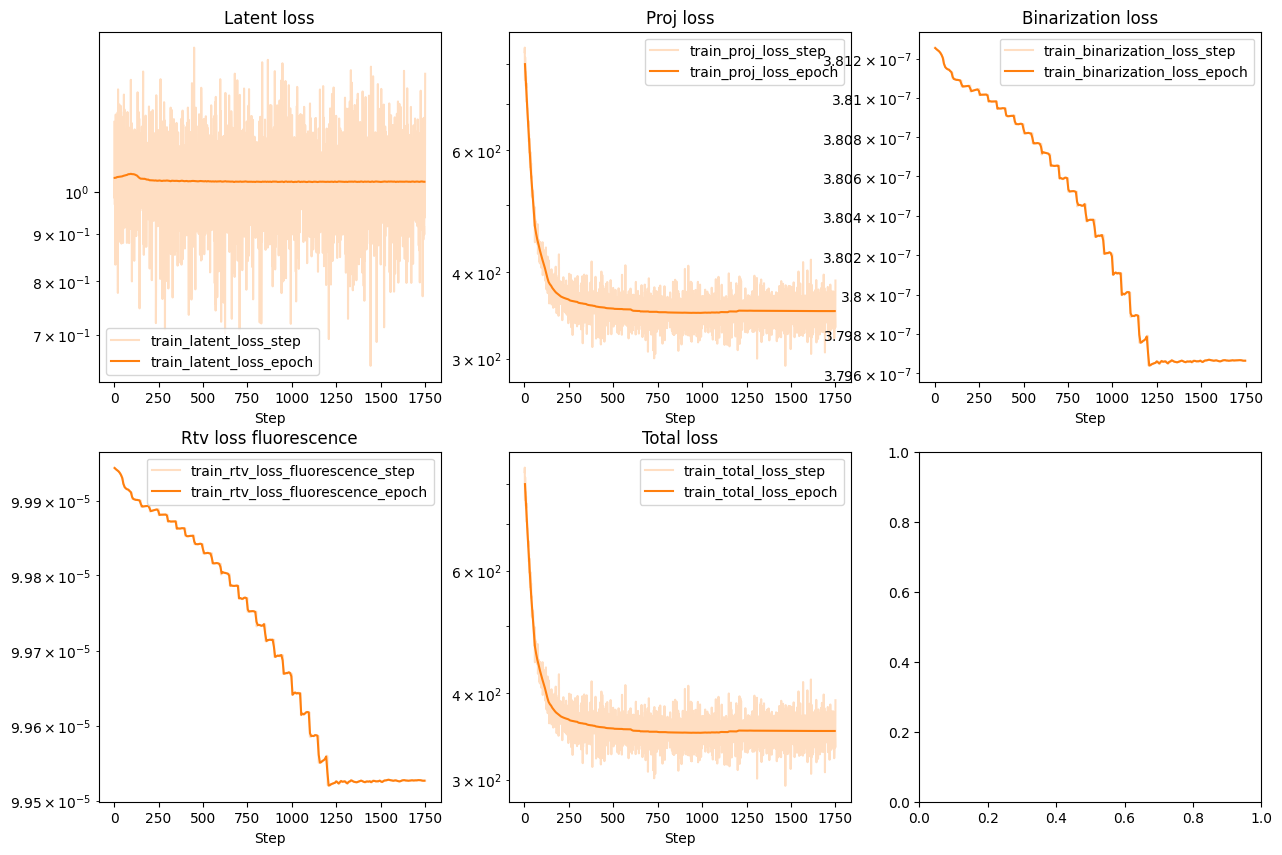

In [ ]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

### 4.2 Optimize the 3D volume and the rotation parameters

In [ ]:
epochs_object_rot = 250 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 16 # Batch size for the object and rotation optimization

In [ ]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
# tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...


  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 169 K  | train
1 | encoder       | Sequential             | 79.2 K | train
2 | fc_mu         | MultiLayerPerceptron   | 8.2 K  | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
-----------------------------------------------------------------
60        Trainable params
169 K     Non-trainable params
169 K     Total params
0.680     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches 

Epoch 249: 100%|██████████| 14/14 [00:16<00:00,  0.84it/s, v_num=11, train_latent_loss_step=1.190, train_proj_loss_step=164.0, train_binarization_loss_step=3.79e-7, train_rtv_loss_fluorescence_step=9.94e-5, train_total_loss_step=165.0, train_latent_loss_epoch=1.000, train_proj_loss_epoch=171.0, train_binarization_loss_epoch=3.79e-7, train_rtv_loss_fluorescence_epoch=9.94e-5, train_total_loss_epoch=172.0]
Training time:  70.2575982093811  minutes


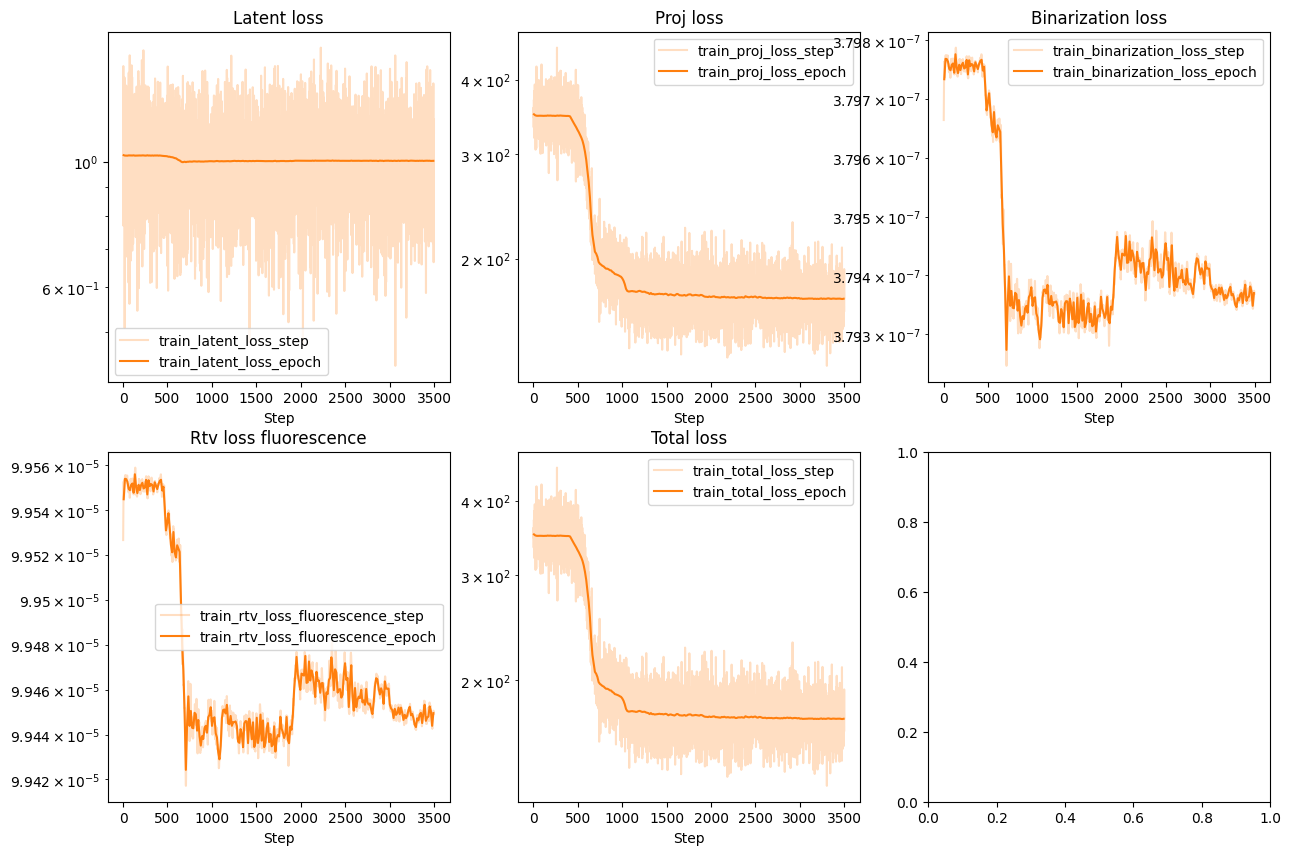

In [ ]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 5.  Evaluate & Visualize

In [ ]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

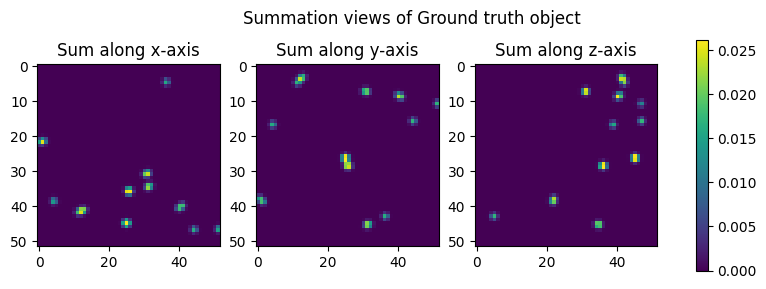

In [ ]:
volume = tomographic_model.get_volume().cpu().detach().numpy()
plotter.plot_sum_object(obj=volume[6:-6, 6:-6, 6:-6], save_name="Ground truth object")

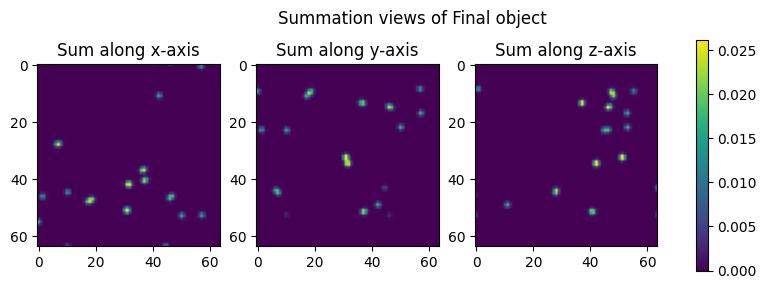

In [ ]:
plotter.plot_sum_object(save_name="Final object")

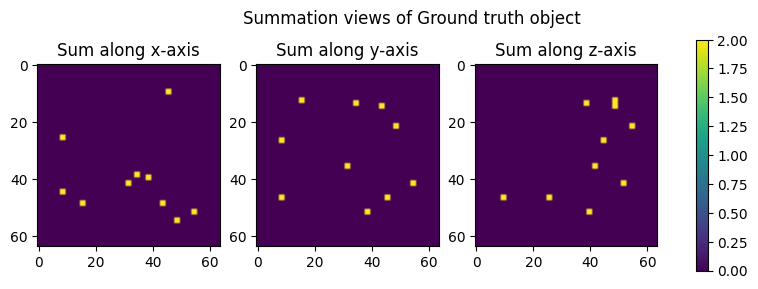

In [ ]:
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

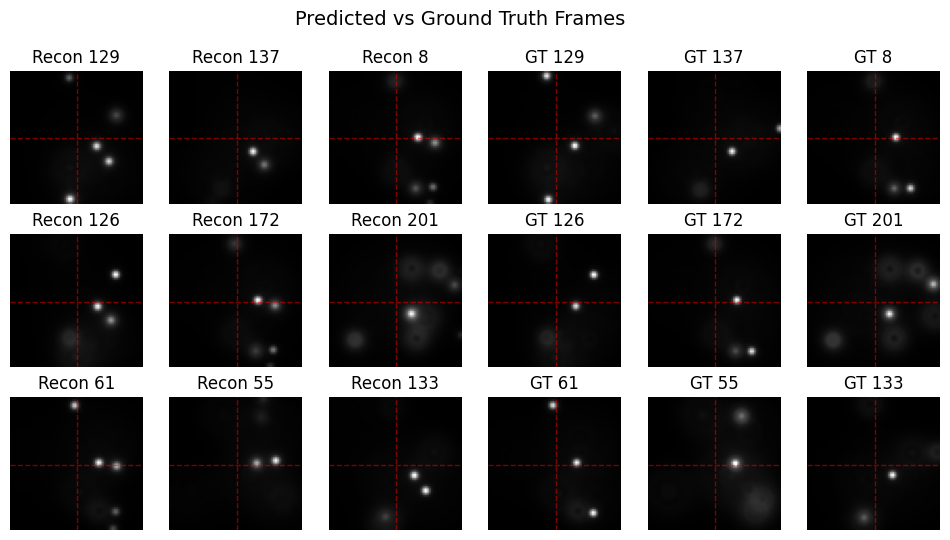

In [ ]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

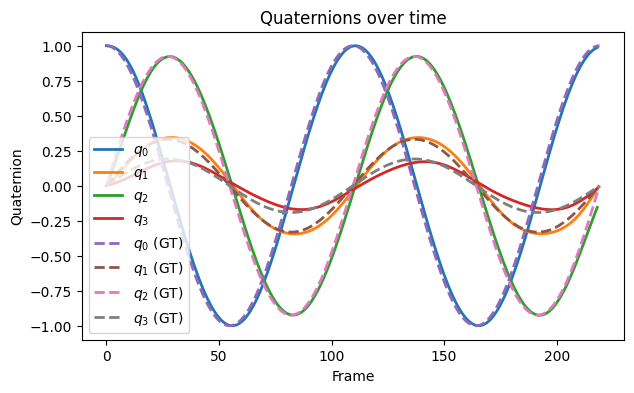

In [ ]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [ ]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 6. Save Result

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [ ]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)



In [ ]:
tomographic_model.move_all_to_device(DEV)
idx = np.random.randint(0, len(tomographic_model.frames), 10)

forward_projections = tomographic_model.full_forward_final(max_projections=10, idx=idx)

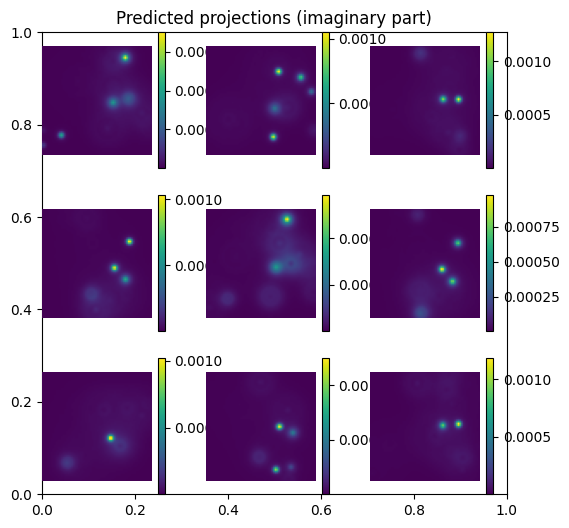

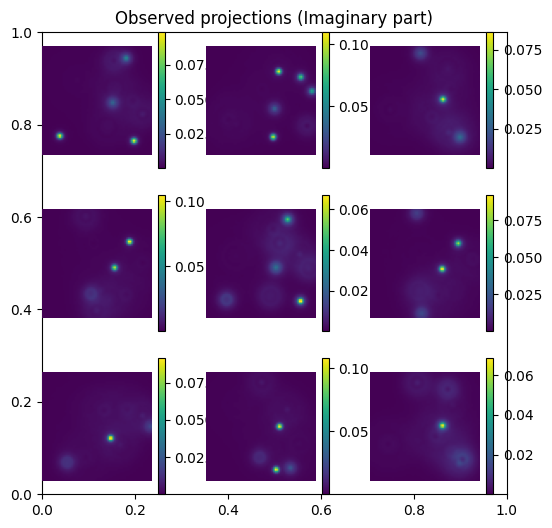

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.title("Predicted projections (imaginary part)")
for i in range(9):
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()

"""""
plt.figure(figsize=(6, 6))
plt.title("Predicted projections (real part)")
for i in range(9):
    proj_upd = forward_projections[i, 0].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd)
    plt.colorbar()
    plt.axis('off')
plt.show()
"""

# show projections
plt.figure(figsize=(6, 6))
plt.title("Observed projections (Imaginary part)")
for i, idx_ in enumerate(idx):
    if i >= 9:
        break
    proj_upd = tomographic_model.frames[idx_].detach().cpu().numpy()
    plt.subplot(3, 3, i + 1)
    plt.imshow(proj_upd[0])
    plt.colorbar()
    plt.axis('off')
plt.show()

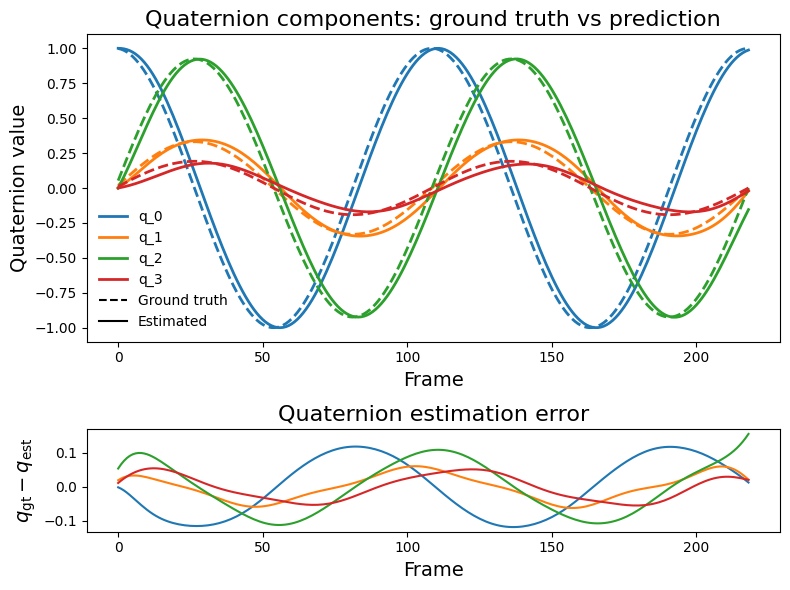

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Your real data here
gt = q_gt[1:].cpu().numpy()
pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
diff = gt - pred
frames = np.arange(len(gt))

# -------------------------------------------------
# Shared scaling for GT and Prediction
# -------------------------------------------------
vmin = min(gt.min(), pred.min())
vmax = max(gt.max(), pred.max())

# -------------------------------------------------
# Create figure: top = components, bottom = error
# -------------------------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1]}
)

# -------------------------------------------------
# TOP: Quaternion components (GT vs estimated)
# -------------------------------------------------

for i in range(4):
    line_gt, = axs[0].plot(frames, gt[:, i], linestyle="dashed", linewidth=2)
    axs[0].plot(frames, pred[:, i], linewidth=2, color=line_gt.get_color(), label=f'q_{i}')

axs[0].set_xlabel("Frame", fontsize=14)
axs[0].set_ylabel("Quaternion value", fontsize=14)
axs[0].set_title("Quaternion components: ground truth vs prediction", fontsize=16)

# Minimal legend: only 2 entries
axs[0].plot([], [], linestyle="dashed", label="Ground truth", color='black')
axs[0].plot([], [], label="Estimated", color='black')
axs[0].legend(frameon=False)

# -------------------------------------------------
# BOTTOM: Quaternion error over time (L2 in R^4)
# -------------------------------------------------
axs[1].plot(frames, diff)
axs[1].set_xlabel("Frame", fontsize=14)
axs[1].set_ylabel(r"$q_{\mathrm{gt}} - q_{\mathrm{est}}$", fontsize=14)
axs[1].set_title("Quaternion estimation error", fontsize=16)

plt.tight_layout()
plt.savefig("C:\\Users\\Fredrik\\Desktop\\fluo_quat.png", dpi=300)


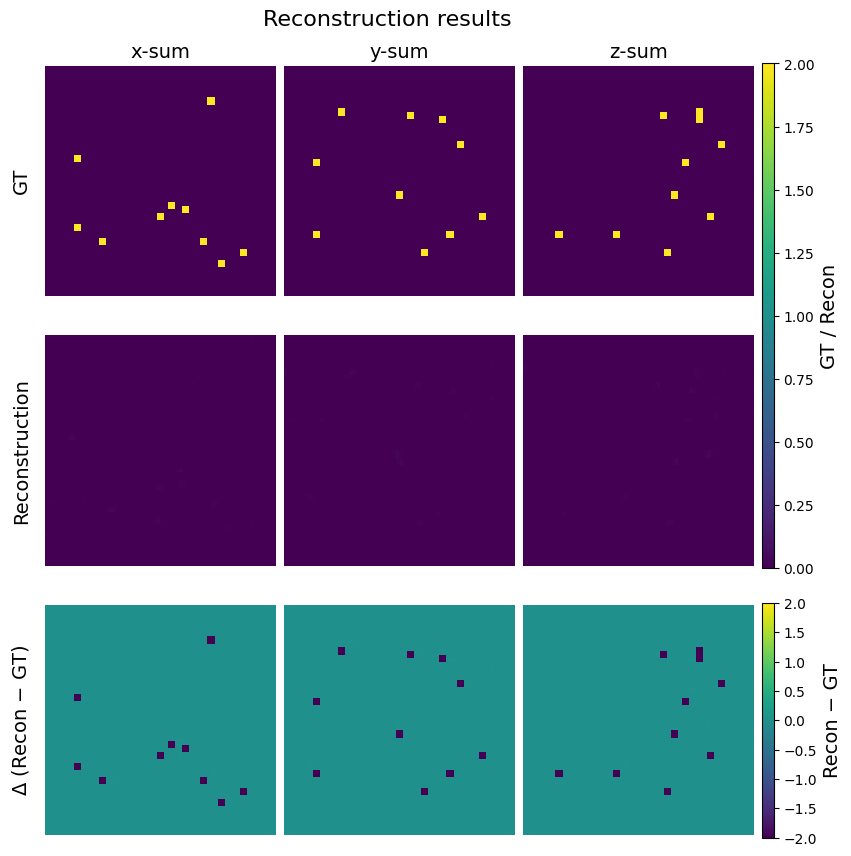

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Replace with your real volumes (same shape)
# -------------------------------------------------
vol_gt  = test_object.cpu().numpy()    # shape (Nx, Ny, Nz)
vol_rec = tomographic_model.get_volume().detach().cpu().numpy()   # shape (Nx, Ny, Nz)


# -------------------------------------------------
# Summed projections
# -------------------------------------------------
gt_x = vol_gt.sum(axis=0)
gt_y = vol_gt.sum(axis=1)
gt_z = vol_gt.sum(axis=2)

rec_x = vol_rec.sum(axis=0)
rec_y = vol_rec.sum(axis=1)
rec_z = vol_rec.sum(axis=2)

# ✅ SIGNED difference
diff_x = rec_x - gt_x
diff_y = rec_y - gt_y
diff_z = rec_z - gt_z

# -------------------------------------------------
# Scaling
# -------------------------------------------------
# Shared scaling for GT & reconstruction
vmin = min(gt_x.min(), gt_y.min(), gt_z.min(),
           rec_x.min(), rec_y.min(), rec_z.min())
vmax = max(gt_x.max(), gt_y.max(), gt_z.max(),
           rec_x.max(), rec_y.max(), rec_z.max())

# ✅ Symmetric scaling for SIGNED difference
diff_max = max(
    np.abs(diff_x).max(),
    np.abs(diff_y).max(),
    np.abs(diff_z).max()
)

# -------------------------------------------------
# Figure with explicit colorbar axes using GridSpec
# -------------------------------------------------
fig = plt.figure(figsize=(9, 9))
gs = fig.add_gridspec(
    3, 4,
    width_ratios=[1, 1, 1, 0.05],
    wspace=0.05,
    hspace=0.15
)

axs = [[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(3)]

cax_top = fig.add_subplot(gs[0:2, 3])  # GT + Recon
cax_bot = fig.add_subplot(gs[2, 3])    # Difference

# --- Row 1: Ground truth ---
im_gt0 = axs[0][0].imshow(gt_x, vmin=vmin, vmax=vmax)
axs[0][0].set_title("x-sum", fontsize=14); axs[0][0]

axs[0][1].imshow(gt_y, vmin=vmin, vmax=vmax)
axs[0][1].set_title("y-sum", fontsize=14); axs[0][1]

axs[0][2].imshow(gt_z, vmin=vmin, vmax=vmax)
axs[0][2].set_title("z-sum", fontsize=14); axs[0][2]

# --- Row 2: Reconstruction ---
axs[1][0].imshow(rec_x, vmin=vmin, vmax=vmax)

axs[1][1].imshow(rec_y, vmin=vmin, vmax=vmax)
axs[1][2].imshow(rec_z, vmin=vmin, vmax=vmax)

# --- Row 3: SIGNED difference ---
im_d0 = axs[2][0].imshow(diff_x, vmin=-diff_max, vmax=diff_max)
axs[2][1].imshow(diff_y, vmin=-diff_max, vmax=diff_max)
axs[2][2].imshow(diff_z, vmin=-diff_max, vmax=diff_max)

for i in range(3):
    for j in range(3):
        ax = axs[i][j]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)


plt.subplots_adjust(left=0.12, right=0.93, top=0.92, bottom=0.06)

# Row labels on the left
axs[0][0].set_ylabel("GT", fontsize=14, rotation=90, labelpad=10)
axs[1][0].set_ylabel("Reconstruction", fontsize=14, rotation=90, labelpad=10)
axs[2][0].set_ylabel(r"$\Delta$ (Recon − GT)", fontsize=14, rotation=90, labelpad=10)

# -------------------------------------------------
# Proper colorbars
# -------------------------------------------------
fig.colorbar(im_gt0, cax=cax_top)
cax_top.set_ylabel("GT / Recon", fontsize=14)

fig.colorbar(im_d0, cax=cax_bot)
cax_bot.set_ylabel("Recon − GT", fontsize=14)

fig.suptitle("Reconstruction results", fontsize=16)

plt.show()
